# Plotting

`exptoolkit.plotter` separates **what to plot** from **which plotting backend is
used**.

A `Plotter` operates on the small `Target` protocol. The same plotting
definition can therefore be used with Matplotlib, Plotly, PyQtGraph, OpenPyXL,
or XlsxWriter targets.

This notebook uses one synthetic TGA dataset throughout.

In [1]:
import numpy as np
import polars as pl

from exptoolkit.data import BaseData, Column, Role
from exptoolkit.plotter import Plotter, XyPlotter

## Example data

In [2]:
class TGA(BaseData):
    time = Column(pl.Float64, base_unit="s", role=Role.INTENSIVE)
    temperature = Column(pl.Float64, base_unit="degC", role=Role.INTENSIVE)
    weight = Column(pl.Float64, base_unit="mg", role=Role.EXTENSIVE)
    dtg = Column(pl.Float64, base_unit="mg/s", role=Role.EXTENSIVE)


time = np.arange(0.0, 1801.0, 10.0)
temperature = 25.0 + 0.25 * time

loss_1 = 1.2 / (1.0 + np.exp(-(temperature - 220.0) / 18.0))
loss_2 = 3.4 / (1.0 + np.exp(-(temperature - 500.0) / 35.0))
weight = 20.0 - loss_1 - loss_2

data = TGA(
    pl.DataFrame(
        {
            "time": time,
            "temperature": temperature,
            "weight": weight,
        }
    )
)
data.dtg = np.gradient(data.weight.to_numpy(), data.time.to_numpy())

normalized = data.normalize(data.weight[0], "mg")

## `XyPlotter`

`XyPlotter` is the simplest reusable plot definition. It selects two columns,
optionally converts their units, and lets the backend-specific target do the
actual rendering.

In [3]:
weight_plot = XyPlotter(
    xcol="temperature",
    ycol="weight",
    yunit="%",
)

## Matplotlib

Pass a Matplotlib `Axes` directly. `get_target()` selects the appropriate
adapter automatically.

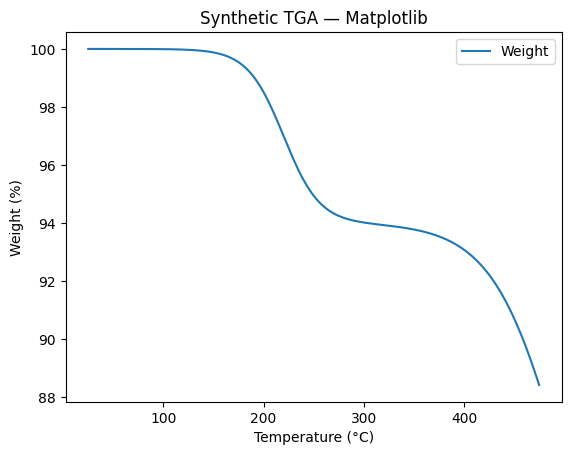

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
weight_plot.plot(
    normalized,
    ax,
    label="Weight",
    color="C0",
)
ax.set_title("Synthetic TGA — Matplotlib")
ax.legend()
plt.show()

## Plotly

The exact same `XyPlotter` can target a Plotly `Figure`.

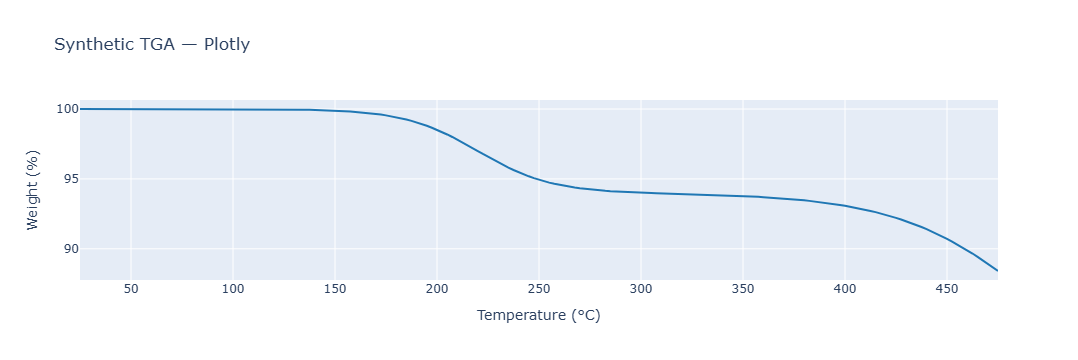

In [5]:
try:
    import plotly.graph_objects as go
except ImportError:
    print("Plotly is not installed; skipping this example.")
else:
    fig = go.Figure()
    weight_plot.plot(
        normalized,
        fig,
        label="Weight",
        color="C0",
    )
    fig.update_layout(title="Synthetic TGA — Plotly")
    fig.show()

## A data-specific plotter

For plots with domain-specific meaning, define a small `Plotter` implementation
once and reuse it across backends.

This example overlays normalized mass and DTG on one target. The purpose here
is not to produce a canonical TGA presentation, but to demonstrate that the
plot definition itself is backend-independent.

In [6]:
class DtgPlotter(Plotter[TGA]):
    def _plot(self, data, target, label=None, color=None, **opts):
        target.add_line(
            data.temperature,
            data.col_to_unit("dtg", "%/s"),
            label=label or "DTG",
            color=color,
            **opts,
        )
        target.set_ax_label("x", "Temperature (degC)")
        target.set_ax_label("y", "DTG (%/s)")
        target.set_title("Synthetic TGA — custom Plotter")


dtg_plot = DtgPlotter()

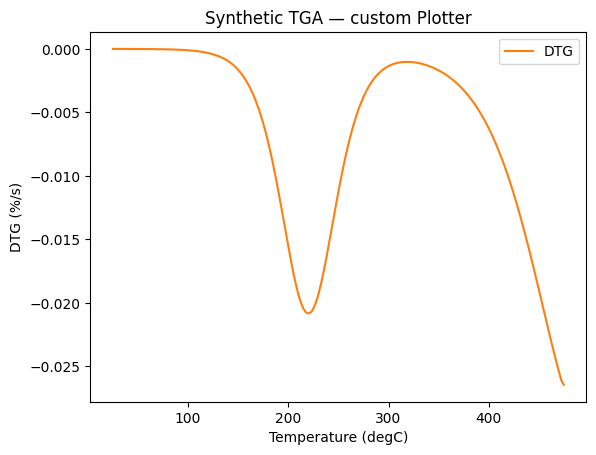

In [7]:
fig, ax = plt.subplots()
dtg_plot.plot(normalized, ax, color="C1")
ax.legend()
plt.show()

The same custom plotter can be sent to Plotly without changing its
implementation.

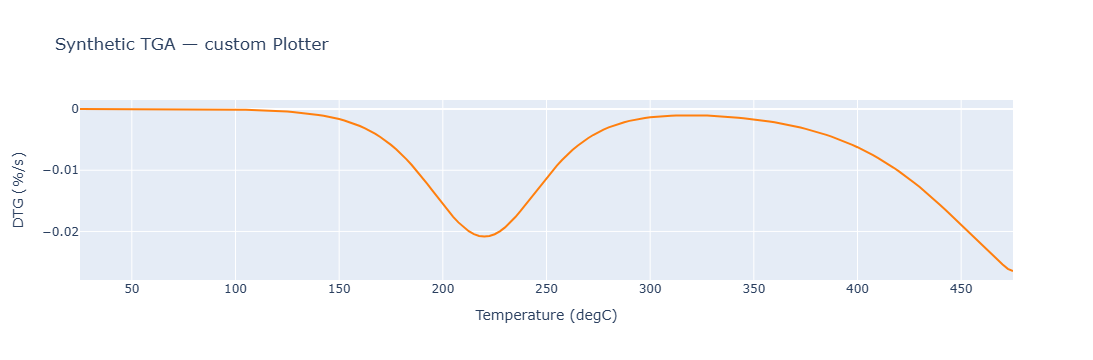

In [8]:
try:
    import plotly.graph_objects as go
except ImportError:
    print("Plotly is not installed; skipping this example.")
else:
    fig = go.Figure()
    dtg_plot.plot(normalized, fig, color="C1")
    fig.show()

## OpenPyXL

Spreadsheet backends use the same plotting API. The generated workbook is kept
in memory here so the example does not create files in the repository.

In [9]:
from io import BytesIO

try:
    from openpyxl import Workbook
    from openpyxl.chart import ScatterChart
except ImportError:
    print("openpyxl is not installed; skipping this example.")
else:
    wb = Workbook()
    ws = wb.active
    ws.title = "TGA"

    chart = ScatterChart()
    chart.x_axis.delete = False
    chart.y_axis.delete = False
    chart.varyColors = False

    weight_plot.plot(
        normalized,
        (ws, chart),
        label="Weight",
        color="C0",
    )
    ws.add_chart(chart, "A10")

    buffer = BytesIO()
    wb.save(buffer)
    print(f"Generated OpenPyXL workbook: {len(buffer.getvalue()):,} bytes")

Generated OpenPyXL workbook: 10,409 bytes


## XlsxWriter

The XlsxWriter backend follows the same pattern. A workbook and worksheet are
passed as the target-like object and the adapter manages the chart.

In [10]:
from io import BytesIO

try:
    from xlsxwriter import Workbook as XlsxWorkbook
except ImportError:
    print("XlsxWriter is not installed; skipping this example.")
else:
    buffer = BytesIO()

    with XlsxWorkbook(buffer, {"in_memory": True}) as wb:
        ws = wb.add_worksheet("TGA")
        weight_plot.plot(
            normalized,
            (wb, ws),
            label="Weight",
            color="C0",
        )

    print(f"Generated XlsxWriter workbook: {len(buffer.getvalue()):,} bytes")

Generated XlsxWriter workbook: 14,683 bytes


## PyQtGraph

PyQtGraph is a desktop GUI backend, so it does not fit naturally into an
automatically executed notebook. The adapter is used in the same way, however.

Set `RUN_PYQTGRAPH = True` when running locally in a GUI-capable environment.

In [11]:
RUN_PYQTGRAPH = False

if RUN_PYQTGRAPH:
    import pyqtgraph as pg

    pg.setConfigOption("background", "w")
    pg.setConfigOption("foreground", "k")

    plot_widget = pg.plot(title="Synthetic TGA — PyQtGraph")
    weight_plot.plot(
        normalized,
        plot_widget,
        label="Weight",
        color="C0",
    )
    pg.exec()

## The point of the abstraction

The plotting code above changes backend objects, not data-processing code:

```python
plotter.plot(data, matplotlib_axes)
plotter.plot(data, plotly_figure)
plotter.plot(data, (openpyxl_worksheet, chart))
plotter.plot(data, (xlsxwriter_workbook, worksheet))
plotter.plot(data, pyqtgraph_plot_widget)
```

A domain package can therefore define its plots once while applications choose
the rendering backend that fits the job.